In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import pandas as pd

plt.rcdefaults()
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

def normalize(series, a, b):
    min = np.min(series)
    max = np.max(series)
    normalized = a + ((series - min) / (max - min)) * (b - a)
    return normalized


def build_dataset_MLP(input, target, ampl_variation, N_train, N_virtual_node, future_step):
    X_train = np.zeros((N_train, N_virtual_node * ampl_variation))
    Y_train = np.zeros(N_train)
    for i in range(N_train):
        for j in range(ampl_variation):
            X_train[i, j*N_virtual_node:(j+1)*N_virtual_node] = input[j][i:(i+N_virtual_node)]
        Y_train[i] = target[N_virtual_node+i+(future_step-1)]

    X_test = np.zeros((N_test, N_virtual_node * ampl_variation))
    Y_test = np.zeros(N_test)
    for i in range(N_test):
        for j in range(ampl_variation):
            X_test[i, j*N_virtual_node:(j+1)*N_virtual_node] = input[j][(N_train+i): (N_train+N_virtual_node+i)]
        Y_test[i] = target[N_train+N_virtual_node+i+(future_step-1)]

    return X_train, Y_train, X_test, Y_test


def add_awgn_noise(signal, snr_db, noise_seed=None):
    # Add noise to the original series
    signal = np.asarray(signal, dtype=float)

    if snr_db is None or np.isposinf(snr_db):
        noisy_signal = signal.copy()
        noise = np.zeros_like(signal)

        return noisy_signal

    signal_power = np.mean(signal ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise_std = np.sqrt(noise_power)

    rng = np.random.default_rng(noise_seed)
    noise = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=signal.shape
    )

    noisy_signal = signal + noise

    return noisy_signal

    
df = pd.read_csv('continuous dataset.csv')
ele_load = np.array(df)[:, 1]

start = 7487 
end = start + 2000

ele_load_select = ele_load[start:end]
ele_load_normalized = normalize(ele_load_select, 0, 1)


### MLP 450 * 64 * 1

- snr = np.inf

In [ ]:
# Generate input mask
rng = np.random.default_rng(0)
input_ampl = rng.uniform(0.0, 1.0, size=9).astype(np.float64)

ele_load_input_variant = np.zeros((len(input_ampl), len(ele_load_normalized)))
ele_load_input_variant_noisy = np.zeros((len(input_ampl), len(ele_load_normalized)))

SNR_DB = np.inf

for i in range(len(input_ampl)):
    ele_load_input_variant[i] = ele_load_normalized * input_ampl[i]
    ele_load_input_variant_noisy[i] = add_awgn_noise(ele_load_input_variant[i], snr_db=SNR_DB, noise_seed=0)


################ dataset preparation ################
N_virtual_node = 50 # use 50 time steps to predict the next one step
N_train = 1200
N_test = 500
ampl_variation = 9

future_steps = np.arange(1, 31)
seeds = np.arange(5)

################ store results ################
nmse_test_all = np.zeros((len(future_steps), len(seeds)))

################ loop over future_step ################
for i, future_step in enumerate(future_steps):

    print("=" * 60)
    print(f"future_step = {future_step}")
    print("=" * 60)

    # Build dataset once for each future_step
    X_train, Y_train, X_test, Y_test = build_dataset_MLP(
        ele_load_input_variant_noisy,
        ele_load_normalized,
        ampl_variation=ampl_variation,
        N_train=N_train,
        N_virtual_node=N_virtual_node,
        future_step=future_step
    )

    Y_train_1d = Y_train.ravel()
    Y_test_1d = Y_test.ravel()

    # Standardize once for each future_step
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = X_scaler.fit_transform(X_train)
    X_test_scaled = X_scaler.transform(X_test)

    y_train_scaled = y_scaler.fit_transform(
        Y_train_1d.reshape(-1, 1)
    ).ravel()

    for j, seed in enumerate(seeds):

        mlp = MLPRegressor(
            hidden_layer_sizes=(64,),      
            activation='relu',
            solver='adam',
            alpha=1e-2,
            batch_size=32,
            learning_rate_init=5e-4,
            max_iter=500,                  
            tol=1e-4,                    
            n_iter_no_change=20,           
            early_stopping=False,
            random_state=int(seed),
            verbose=False,
        )

        mlp.fit(X_train_scaled, y_train_scaled)

        Y_test_predict_scaled = mlp.predict(X_test_scaled)

        Y_test_predict = y_scaler.inverse_transform(
            Y_test_predict_scaled.reshape(-1, 1)
        ).ravel()

        nmse_test = np.mean((Y_test_predict - Y_test_1d) ** 2) / np.var(Y_test_1d)
        nrmse_test = np.sqrt(nmse_test)

        nmse_test_all[i, j] = nmse_test

    print(
        f"averaged test NMSE={np.mean(nmse_test_all[i, :]):.6f}"
    )

nmse_test_mean_no_noise = np.mean(nmse_test_all, axis=1)
nmse_test_std_no_noise = np.std(nmse_test_all, axis=1)

np.savetxt('Panama_MLP_nmse_test_mean_no_noise.txt', nmse_test_mean_no_noise)
np.savetxt('Panama_MLP_nmse_test_std_no_noise.txt', nmse_test_std_no_noise)

future_step = 1
averaged test NMSE=0.012798
future_step = 2
averaged test NMSE=0.030432
future_step = 3
averaged test NMSE=0.049913
future_step = 4
averaged test NMSE=0.074549
future_step = 5
averaged test NMSE=0.101633
future_step = 6
averaged test NMSE=0.133845
future_step = 7
averaged test NMSE=0.147754
future_step = 8
averaged test NMSE=0.156738
future_step = 9
averaged test NMSE=0.165271
future_step = 10
averaged test NMSE=0.171173
future_step = 11
averaged test NMSE=0.182608
future_step = 12
averaged test NMSE=0.199590
future_step = 13
averaged test NMSE=0.192940
future_step = 14
averaged test NMSE=0.187842
future_step = 15
averaged test NMSE=0.175723
future_step = 16
averaged test NMSE=0.176961
future_step = 17
averaged test NMSE=0.164238
future_step = 18
averaged test NMSE=0.164379
future_step = 19
averaged test NMSE=0.171627
future_step = 20
averaged test NMSE=0.195211
future_step = 21
averaged test NMSE=0.202205
future_step = 22
averaged test NMSE=0.198795
future_step = 23
av

- SNR = 30 dB

In [ ]:
# Generate input mask
rng = np.random.default_rng(0)
input_ampl = rng.uniform(0.0, 1.0, size=9).astype(np.float64)

ele_load_input_variant = np.zeros((len(input_ampl), len(ele_load_normalized)))
ele_load_input_variant_noisy = np.zeros((len(input_ampl), len(ele_load_normalized)))

SNR_DB = 30

for i in range(len(input_ampl)):
    ele_load_input_variant[i] = ele_load_normalized * input_ampl[i]
    ele_load_input_variant_noisy[i] = add_awgn_noise(ele_load_input_variant[i], snr_db=SNR_DB, noise_seed=0)


################ dataset preparation ################
N_virtual_node = 50 # use 50 time steps to predict the next one step
N_train = 1200
N_test = 500
ampl_variation = 9

future_steps = np.arange(1, 31)
seeds = np.arange(5)

################ store results ################
nmse_test_all = np.zeros((len(future_steps), len(seeds)))

################ loop over future_step ################
for i, future_step in enumerate(future_steps):

    print("=" * 60)
    print(f"future_step = {future_step}")
    print("=" * 60)

    # Build dataset once for each future_step
    X_train, Y_train, X_test, Y_test = build_dataset_MLP(
        ele_load_input_variant_noisy,
        ele_load_normalized,
        ampl_variation=ampl_variation,
        N_train=N_train,
        N_virtual_node=N_virtual_node,
        future_step=future_step
    )

    Y_train_1d = Y_train.ravel()
    Y_test_1d = Y_test.ravel()

    # Standardize once for each future_step
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = X_scaler.fit_transform(X_train)
    X_test_scaled = X_scaler.transform(X_test)

    y_train_scaled = y_scaler.fit_transform(
        Y_train_1d.reshape(-1, 1)
    ).ravel()

    for j, seed in enumerate(seeds):

        mlp = MLPRegressor(
            hidden_layer_sizes=(64,),      
            activation='relu',
            solver='adam',
            alpha=1e-2,
            batch_size=32,
            learning_rate_init=5e-4,
            max_iter=500,                  
            tol=1e-4,                    
            n_iter_no_change=20,           
            early_stopping=False,
            random_state=int(seed),
            verbose=False,
        )

        mlp.fit(X_train_scaled, y_train_scaled)

        Y_test_predict_scaled = mlp.predict(X_test_scaled)

        Y_test_predict = y_scaler.inverse_transform(
            Y_test_predict_scaled.reshape(-1, 1)
        ).ravel()

        nmse_test = np.mean((Y_test_predict - Y_test_1d) ** 2) / np.var(Y_test_1d)
        nrmse_test = np.sqrt(nmse_test)

        nmse_test_all[i, j] = nmse_test

    print(
        f"averaged test NMSE={np.mean(nmse_test_all[i, :]):.6f}"
    )

nmse_test_mean_snr30 = np.mean(nmse_test_all, axis=1)
nmse_test_std_snr30 = np.std(nmse_test_all, axis=1)

np.savetxt('Panama_MLP_nmse_test_mean_snr30.txt', nmse_test_mean_snr30)
np.savetxt('Panama_MLP_nmse_test_std_snr30.txt', nmse_test_std_snr30)

future_step = 1
averaged test NMSE=0.019231
future_step = 2
averaged test NMSE=0.044139
future_step = 3
averaged test NMSE=0.057661
future_step = 4
averaged test NMSE=0.074541
future_step = 5
averaged test NMSE=0.097693
future_step = 6
averaged test NMSE=0.151425
future_step = 7
averaged test NMSE=0.158996
future_step = 8
averaged test NMSE=0.180470
future_step = 9
averaged test NMSE=0.194840
future_step = 10
averaged test NMSE=0.213693
future_step = 11
averaged test NMSE=0.211368
future_step = 12
averaged test NMSE=0.211965
future_step = 13
averaged test NMSE=0.207592
future_step = 14
averaged test NMSE=0.203232
future_step = 15
averaged test NMSE=0.201535
future_step = 16
averaged test NMSE=0.184244
future_step = 17
averaged test NMSE=0.190535
future_step = 18
averaged test NMSE=0.171247
future_step = 19
averaged test NMSE=0.196948
future_step = 20
averaged test NMSE=0.197469
future_step = 21
averaged test NMSE=0.186807
future_step = 22
averaged test NMSE=0.201627
future_step = 23
av

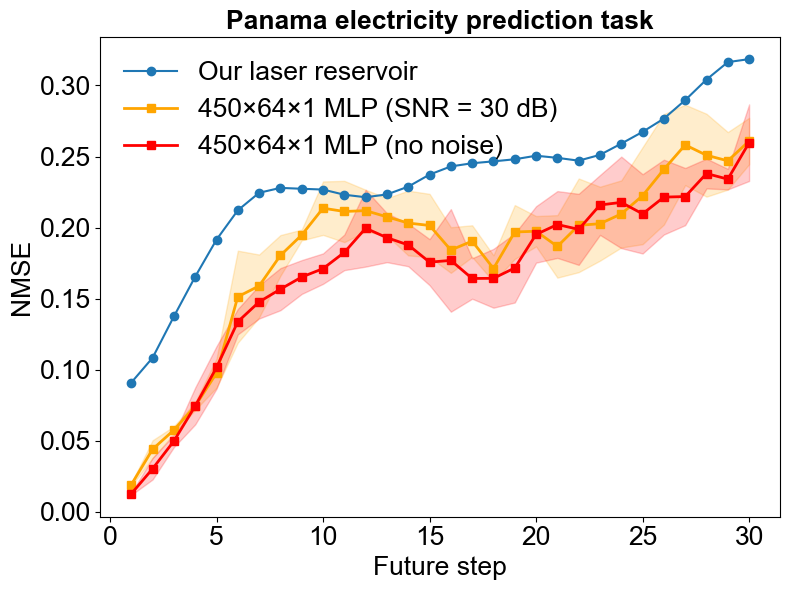

In [4]:
future_steps = np.arange(1, 31)

nmse_test_mean_snr30 = np.loadtxt('Panama_MLP_nmse_test_mean_snr30.txt')
nmse_test_std_snr30 = np.loadtxt('Panama_MLP_nmse_test_std_snr30.txt')

nmse_test_mean_no_noise = np.loadtxt('Panama_MLP_nmse_test_mean_no_noise.txt')
nmse_test_std_no_noise = np.loadtxt('Panama_MLP_nmse_test_std_no_noise.txt')

laser_reservoir = [0.09102033, 0.1084802 , 0.13754019, 0.16551342, 0.19154857,
       0.21218354, 0.22452202, 0.22796996, 0.22735025, 0.22678309,
       0.2231461 , 0.22139397, 0.22337219, 0.22885027, 0.23731738,
       0.24306861, 0.2453    , 0.24662356, 0.24809584, 0.2505902 ,
       0.24909453, 0.24711224, 0.25119823, 0.2591031 , 0.26735613,
       0.27670876, 0.28968776, 0.30416135, 0.31642842, 0.31853488]

plt.figure(figsize=(8, 6))

plt.plot(future_steps, laser_reservoir, marker='o', label='Our laser reservoir')

plt.plot(
    future_steps,
    nmse_test_mean_snr30,
    marker='s',
    linewidth=2,
    label='450×64×1 MLP (SNR = 30 dB)',
    color='orange'
)

plt.fill_between(
    future_steps,
    nmse_test_mean_snr30 - nmse_test_std_snr30,
    nmse_test_mean_snr30 + nmse_test_std_snr30,
    alpha=0.2,
    color='orange'
)

plt.plot(
    future_steps,
    nmse_test_mean_no_noise,
    marker='s',
    linewidth=2,
    label='450×64×1 MLP (no noise)',
    color='red'
)

plt.fill_between(
    future_steps,
    nmse_test_mean_no_noise - nmse_test_std_no_noise,
    nmse_test_mean_no_noise + nmse_test_std_no_noise,
    alpha=0.2,
    color='red'
)

font = 19
plt.xlabel('Future step', fontsize=font)
plt.ylabel('NMSE', fontsize=font)
plt.title('Panama electricity prediction task', fontsize=font, weight='bold')
plt.legend(frameon=0, fontsize=font, loc='upper left')
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.tight_layout()
plt.show()
# plt.savefig('Panama MLP.png', dpi=800, transparent=1)